Cantidad registros: 1988
root
 |-- _id: string (nullable = true)
 |-- antiguedad_auto: integer (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- categoria_precio: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- es_ecologico: integer (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- foto_url: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- rango_kilometraje: string (nullable = true)
 |-- tipo_marca: string (nullable = true)
 |-- url: string (nullable = true)
 |-- uso_anual_estimado: double (nullable = true)
 |-- usuario: string (nullable = true)
 |-- year: integer (nullable = true)

+--------------------+---------------+---------------+----------------+--------+-----------+------------+-------------------+--------+

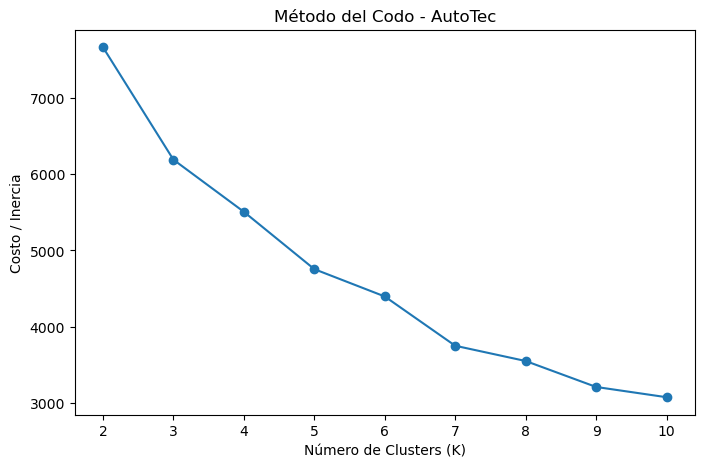

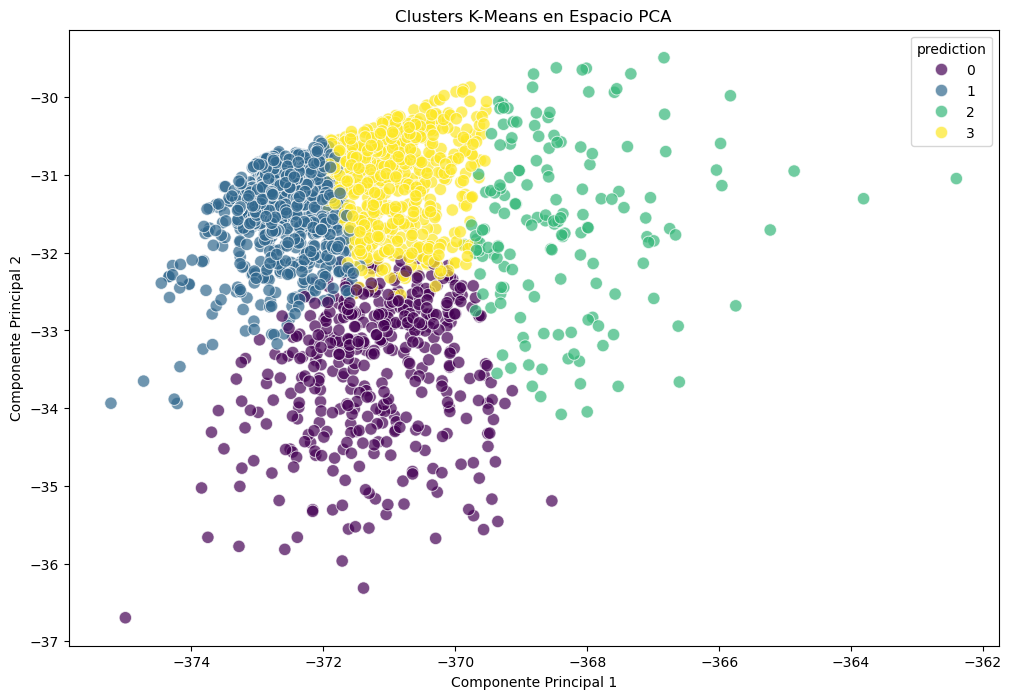

+----------+--------------------+------------------+------------------+------------------+------------------+
|prediction|         avg(precio)|  avg(kilometraje)|         avg(anio)|    avg(cat_marca)|   avg(cat_modelo)|
+----------+--------------------+------------------+------------------+------------------+------------------+
|         1|1.8281021968911916E7| 34459.52461139896|2023.8290155440413|  8.13341968911917| 62.58937823834197|
|         3|1.3368445745682888E7| 99247.42072213501|2020.2778649921506| 7.869701726844584| 93.08163265306122|
|         2|   9741761.006289309|167298.06289308175| 2013.377358490566|14.786163522012579|325.76100628930817|
|         0| 2.030047876190476E7| 59197.05238095238|2021.3095238095239|              21.9|510.43333333333334|
+----------+--------------------+------------------+------------------+------------------+------------------+

+----------+------------+-----+
|prediction|marca_limpia|count|
+----------+------------+-----+
|0         |chevrolet  

In [1]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, trim
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Conexión a MongoDB
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = (
    SparkSession.builder
    .appName("KMeans_AutoTec")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", "proyecto_bigdata")
    .option("collection", "Contenedor_Autos_Limpio")
    .load()
)

print("Cantidad registros:", df.count())
df.printSchema()
df.show(5)

# 2. Preparación de datos
df_clustering = df.select(
    col("precio").cast("double"),
    col("kilometraje").cast("double"),
    col("year").cast("int").alias("anio"),
    lower(trim(col("combustible"))).alias("combustible_limpio"),
    lower(trim(col("marca"))).alias("marca_limpia"),
    lower(trim(col("modelo"))).alias("modelo_limpio")
).dropna()

df_clustering = df_clustering.filter(col("precio") > 0)
df_clustering = df_clustering.filter(col("kilometraje") < 800000)
df_clustering = df_clustering.filter(col("anio") >= 1990)

indexer_combustible = StringIndexer(inputCol="combustible_limpio", outputCol="cat_combustible", handleInvalid="keep")
indexer_marca = StringIndexer(inputCol="marca_limpia", outputCol="cat_marca", handleInvalid="keep")
indexer_modelo = StringIndexer(inputCol="modelo_limpio", outputCol="cat_modelo", handleInvalid="keep")

pipeline = Pipeline(stages=[indexer_combustible, indexer_marca, indexer_modelo])
df_clustering = pipeline.fit(df_clustering).transform(df_clustering)

# 3. Vectorización y escalado
assembler = VectorAssembler(
    inputCols=["precio", "kilometraje", "anio", "cat_marca", "cat_modelo"],
    outputCol="features"
)
df_vector = assembler.transform(df_clustering)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# 4. Método del Codo
cost = []
for k in range(2, 11):
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = kmeans.fit(df_scaled)
    cost.append(model.summary.trainingCost)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), cost, marker='o')
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Costo / Inercia")
plt.title("Método del Codo - AutoTec")
plt.show()

# 5. Modelo final con k=4
k_optimo = 4
kmeans_final = KMeans(featuresCol="scaledFeatures", k=k_optimo, seed=42)
model_final = kmeans_final.fit(df_scaled)
df_clusters = model_final.transform(df_scaled)

# 6. Visualización PCA con predicciones
pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

df_viz = model_final.transform(df_pca)   # aquí se añade 'prediction'
pdf_visual = df_viz.select("pcaFeatures", "prediction").toPandas()
pdf_visual[["PC1","PC2"]] = pd.DataFrame(pdf_visual["pcaFeatures"].apply(lambda x: x.toArray()).tolist())

plt.figure(figsize=(12,8))
sns.scatterplot(data=pdf_visual, x="PC1", y="PC2", hue="prediction", palette="viridis", s=80, alpha=0.7)
plt.title("Clusters K-Means en Espacio PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

# 7. Perfilamiento de clusters
df_clusters.groupBy("prediction").avg("precio","kilometraje","anio","cat_marca","cat_modelo").show()
df_clusters.groupBy("prediction","marca_limpia").count().orderBy("prediction", col("count").desc()).show(20, truncate=False)
df_clusters.groupBy("prediction","modelo_limpio").count().orderBy("prediction", col("count").desc()).show(20, truncate=False)

# 8. Guardar resultados etiquetados
df_clusters.write.mode("overwrite").parquet("/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans")
